# Network Analysis and Visualization with NetworkX

In this workshop we will explore **network analysis** — a powerful technique for understanding relationships between entities — using Python's [NetworkX](https://networkx.org/) library. Networks (also called *graphs*) appear everywhere: social connections, transportation systems, the web, and more.

A network has two fundamental components:
- **Nodes** (vertices) — the entities being connected (e.g., people, places, web pages)
- **Edges** (links) — the relationships between those entities (e.g., friendships, roads, hyperlinks)

By the end of this workshop you will be able to:
1. Build and draw basic networks with NetworkX
2. Construct a real-world network from NYC taxi trip data
3. Compute key network metrics: degree, centrality, shortest path, clustering, and neighbors

## Libraries

We will use the following libraries throughout this workshop:

| Library | Purpose |
|---|---|
| `networkx` | Building, analyzing, and drawing networks |
| `pandas` | Loading and cleaning tabular data |
| `numpy` | Numerical operations |
| `matplotlib` | Low-level plotting |
| `seaborn` | Statistical visualization |
| `json` / `urllib` | Reading remote GeoJSON files |

In [25]:
#python core imports
from urllib.request import urlopen
import json
import numpy as np
import pandas as pd
import random

#visualization imports
import seaborn as sns
from IPython.core.pylabtools import figsize
import matplotlib.pyplot as plt

#python networkx library
import networkx as nx

---
## Part 1: Introduction to NetworkX

Before working with real data, let's get comfortable with the core NetworkX API by building a small graph from scratch.

NetworkX represents graphs as `Graph` objects. We add nodes (any hashable value — numbers, strings, etc.) and edges (pairs of nodes) to the object. The example below creates a simple five-node graph with several edges connecting them.

In [26]:
#create graph object
G = nx.Graph()

#add some nodes
G.add_nodes_from([1, 2, 3, 4, 5])

#add some edges (connections between the nodes) - ie, nodes 1 and 2 are connected, nodes 2 and 3 are connected, etc.
edges=[(1,2), (2,3), (3,1), (1,4), (3,2), (3,5)]
for e in edges:
    G.add_edge(*e, weight=1) #the astrisk "unpacks" the tuple

### Inspecting the Graph

Once a graph is built, we can inspect its nodes and edges directly. NetworkX returns special view objects that behave like lists.

In [27]:
#view the nodes
G.nodes()

NodeView((1, 2, 3, 4, 5))

In [28]:
#view the edges
G.edges()

EdgeView([(1, 2), (1, 3), (1, 4), (2, 3), (3, 5)])

### Drawing the Network

`nx.draw()` provides a quick way to visualize a graph. By default it uses a spring-force layout algorithm to position the nodes. Setting `with_labels=True` renders the node identifiers directly on the plot.

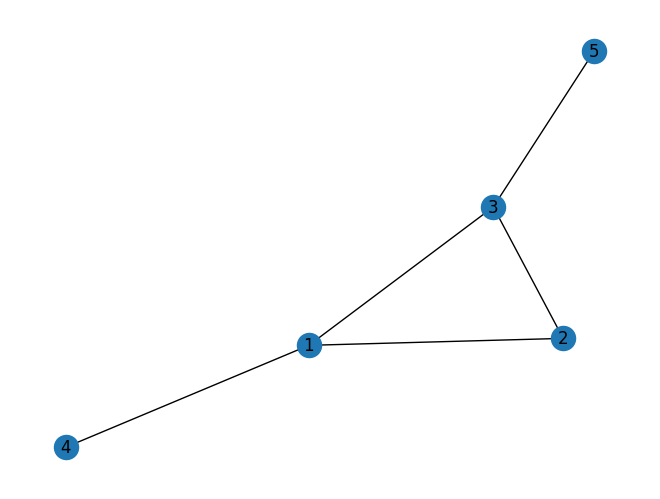

In [29]:
#let's draw the network
nx.draw(G, with_labels=True)
plt.show()

### Visualizing Edge Weights

Edges can carry **attributes** — extra metadata stored as key-value pairs on each edge. A very common attribute is `weight`, which can represent the strength or frequency of a connection (e.g., number of trips, call frequency).

In the cell below we manually increase the weight on one edge and then draw the graph so that heavier edges appear thicker and solid while lighter edges appear thinner and dashed. We also fix the node positions using a `seed` so the layout is reproducible across runs.

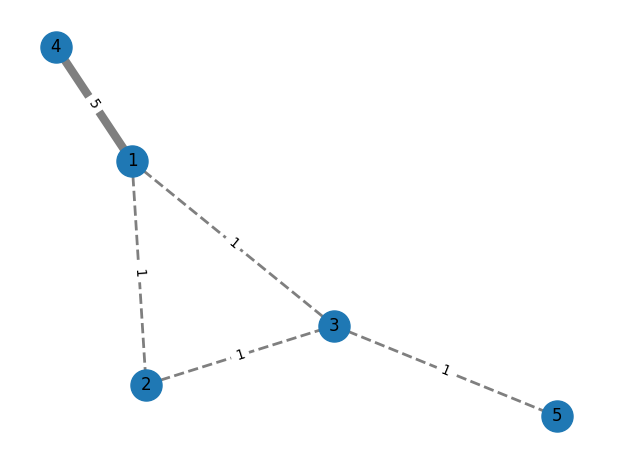

In [30]:
#lets draw it again but add some weights to the edges
G.edges[4,1]['weight']=5

#we'll call any edge with a weight over 1 "large". All the others will be "small"
elarge = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] > 1]
esmall = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] <= 1]

# 1. Define the layout (mandatory for placing labels)
pos = nx.spring_layout(G, seed=1)  # positions for all nodes - setting a seed allows us to make the same visual repeatedly. Otherwise position of nodes is random

# nodes
nx.draw_networkx_nodes(G, pos, node_size=500)

# edges - we'll make our "large" edges 6 pixels wide and our "small" edges 2 pixels
nx.draw_networkx_edges(G, pos, edgelist=elarge, alpha=0.5, width=6, style="solid")
nx.draw_networkx_edges(
    G, pos, edgelist=esmall, width=2, alpha=0.5, edge_color="black", style="dashed"
)

# node labels
nx.draw_networkx_labels(G, pos, font_size=12, font_family="sans-serif")
# edge weight labels
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels)

ax = plt.gca()
ax.margins(0.08)
plt.axis("off")
plt.tight_layout()
plt.show()

---
## Part 2: Real-World Network Data — NYC Taxi Trips

Now that we understand the basics, let's build a network from a real dataset. We will use NYC yellow taxi trip records from June 2018. In this network:
- Each **node** is a NYC taxi zone (a neighborhood-level geographic area)
- Each **edge** connects two zones when at least one taxi ride started in one zone and ended in the other

We also load a GeoJSON file that maps zone IDs to borough names and neighborhood names — this will let us add geographic context to our nodes later.

In [31]:
#read in the geojson file. We'll name it taxi_zones
with urlopen('https://raw.githubusercontent.com/nickxscott/INFO658/refs/heads/main/notebooks/data/taxi.geojson') as response:
    taxi_zones = json.load(response)

#read in taxi data from github
df=pd.read_csv('https://raw.githubusercontent.com/nickxscott/INFO658/refs/heads/main/notebooks/data/taxi_trips_062018.csv')

#perform data cleaning steps from our mapping lab last week
q99=np.nanquantile(df.trip_distance,0.99)
df_clean=df.loc[(df.trip_distance>0)&(df.trip_distance<=q99)]
q99=np.nanquantile(df.fare_amount,0.99)
df_clean=df_clean.loc[(df_clean.fare_amount>0)&(df_clean.fare_amount<=q99)]

#create aa dictionary from which we can add the boro name to our dataframe
zone_boro={}
for zones in taxi_zones['features']:
    zone_id=zones['properties']['locationid']
    boro_name=zones['properties']['borough']
    zone_boro[int(zone_id)]=boro_name

#create new columns for the pickup and drop off boroughs
df_clean['pu_boro']=df_clean.PULocationID.map(zone_boro)
df_clean['do_boro']=df_clean.DOLocationID.map(zone_boro)

#create aa dictionary to store the name of the neighborhood the zone is in. We'll use this later
zone_name={}
for zones in taxi_zones['features']:
    zone_id=zones['properties']['locationid']
    neighborhood_name=zones['properties']['zone']
    zone_name[int(zone_id)]=neighborhood_name


#remove rides with missing start/end boros
df_clean=df_clean.loc[(~df_clean.pu_boro.isna())&(~df_clean.do_boro.isna())]

#remove rides starting from staten island and EWR. We'll stick to just manhattan, queens, brooklyn, and the bronx
df_clean=df_clean.loc[(df_clean.pu_boro!='Staten Island') & (df_clean.do_boro!='Staten Island')&(df_clean.pu_boro!='EWR') & (df_clean.do_boro!='EWR')]

df_clean

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,pu_boro,do_boro
0,1,2018 Jun 01 11:45:00 PM,2018 Jun 02 12:02:49 AM,1,1.70,1,N,45,79,1,12.0,0.5,0.5,2.65,0.0,0.3,15.95,Manhattan,Manhattan
1,1,2018 Jun 01 11:45:00 PM,2018 Jun 01 11:58:16 PM,1,2.30,1,N,163,238,1,11.5,0.5,0.5,1.28,0.0,0.3,14.08,Manhattan,Manhattan
2,1,2018 Jun 01 11:45:00 PM,2018 Jun 01 11:56:15 PM,2,0.90,1,N,79,144,2,8.5,0.5,0.5,0.00,0.0,0.3,9.80,Manhattan,Manhattan
3,2,2018 Jun 01 11:44:59 PM,2018 Jun 02 12:02:15 AM,1,4.82,1,N,68,151,1,17.5,0.5,0.5,3.76,0.0,0.3,22.56,Manhattan,Manhattan
4,2,2018 Jun 01 11:44:59 PM,2018 Jun 02 12:12:30 AM,1,11.83,1,N,237,183,2,36.0,0.5,0.5,0.00,0.0,0.3,37.30,Manhattan,Bronx
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316240,2,2018 Jun 01 12:00:01 AM,2018 Jun 01 12:04:45 AM,6,1.11,1,N,211,231,2,6.0,0.5,0.5,0.00,0.0,0.3,7.30,Manhattan,Manhattan
316241,1,2018 Jun 01 12:00:00 AM,2018 Jun 01 12:20:14 AM,1,4.10,1,N,79,189,1,16.5,0.5,0.5,5.30,0.0,0.3,23.10,Manhattan,Brooklyn
316242,1,2018 Jun 01 12:00:00 AM,2018 Jun 01 12:15:30 AM,1,4.20,1,N,158,238,1,15.0,0.5,0.5,3.25,0.0,0.3,19.55,Manhattan,Manhattan
316243,2,2018 Jun 01 12:00:00 AM,2018 Jun 01 09:42:22 AM,1,1.53,1,N,125,261,1,8.0,0.3,0.5,1.76,0.0,0.0,10.56,Manhattan,Manhattan


### Building the Network Structure

To construct the network we iterate over every row in the cleaned taxi dataset. For each trip we:
1. Add the pickup zone ID as a node (if not already present)
2. Add the dropoff zone ID as a node (if not already present)
3. Add an edge between the two zones — but only if the pickup and dropoff zones are *different* (a ride that starts and ends in the same zone does not represent a meaningful connection)

We store everything in a plain Python dictionary (`d_network`) before handing it off to NetworkX.

In [32]:
d_network={'nodes':[],
         'edges':[]}

for index, row in df_clean.iterrows():
    #add nodes
    if row.PULocationID not in d_network['nodes']:
        d_network['nodes'].append(row.PULocationID)
    if row.DOLocationID not in d_network['nodes']:
        d_network['nodes'].append(row.DOLocationID)

    #add edges - remove edges where start and end are the same station
    if row.PULocationID == row.DOLocationID:
        pass
    else:
        d_network['edges'].append((row.PULocationID, row.DOLocationID))

### Creating the NetworkX Graph Object

With our node and edge lists ready, we create a NetworkX `Graph` object and populate it. Because this is an undirected graph (`nx.Graph`), an edge from zone A to zone B is treated as identical to an edge from zone B to zone A.

In [33]:
#create list of nodes. In this case, it's a list of every unique taxi zone.
nodes=d_network['nodes']

#add edges, 
edges=d_network['edges']

In [34]:
#create graph object
G = nx.Graph()

#add the nodes and edges to the graph object
G.add_nodes_from(nodes)

for e in edges:
    G.add_edge(*e, weight=1) #the astrisk "unpacks" the tuple

---
## Visualizing the Network

Let's draw the taxi zone network. With hundreds of nodes and thousands of edges, the first pass will look cluttered — but it gives us a useful baseline before we add structure.

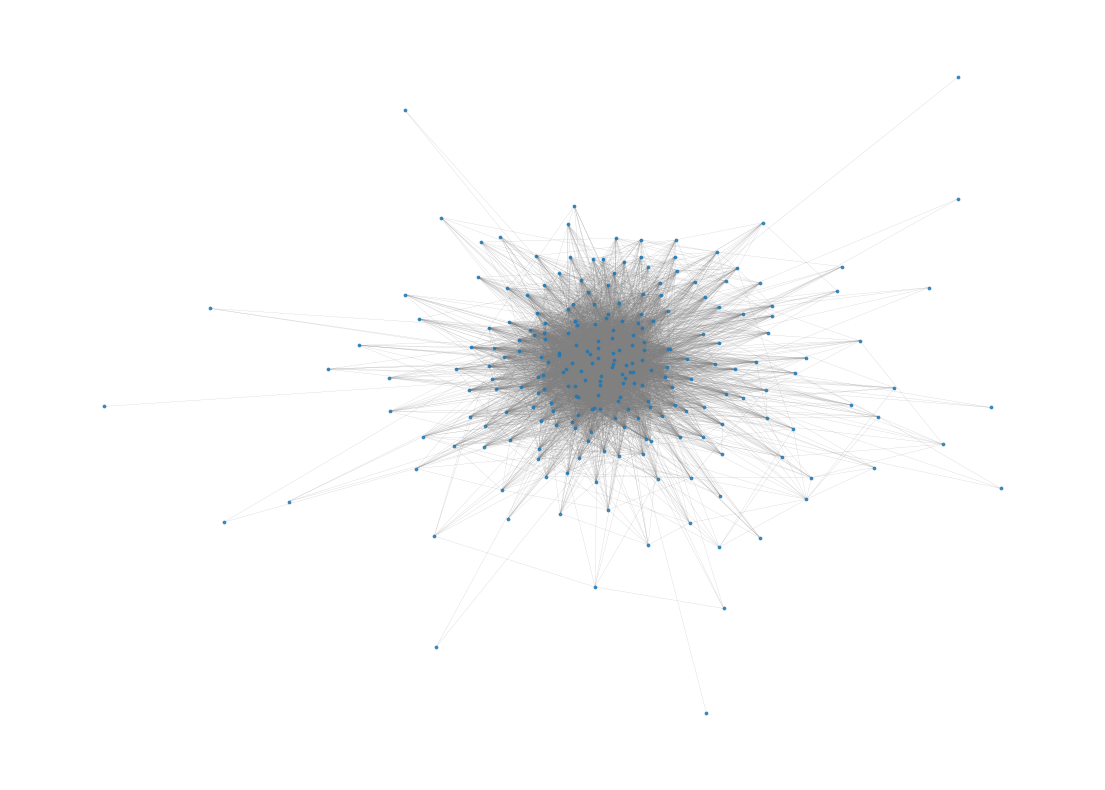

In [35]:
#let's draw the network
fig, ax = plt.subplots(figsize=(14, 10))

nx.draw(G, with_labels=False, node_size=3, width=0.1, edge_color='grey', alpha=0.8, ax=ax)
plt.show()

This looks quite messy. We can add structure by coloring each node according to its borough. To do this we need to attach borough information as a **node attribute** — a dictionary of metadata that NetworkX stores alongside each node. We will create an attribute called `boro` on every node using the `zone_boro` lookup dictionary we built when loading the GeoJSON file.

In [36]:
#node attributes - borough name
for n in G.nodes():
    boro=zone_boro[n]
    G.nodes[n]['boro']=boro

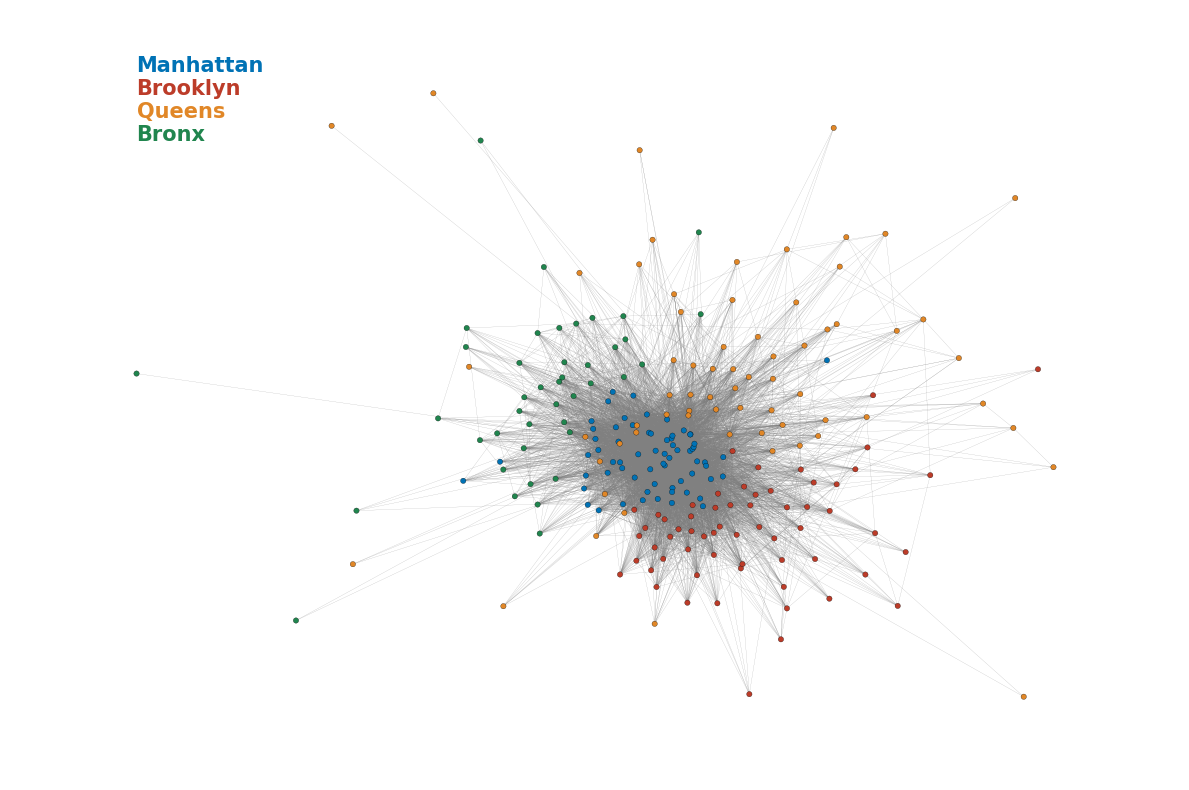

In [37]:
cmap=[]
for n in G.nodes():
    if G.nodes[n]['boro'] == 'Manhattan':
        cmap.append('#0072b5ff')
    elif G.nodes[n]['boro'] == 'Brooklyn':
        cmap.append('#bc3c29ff')
    elif G.nodes[n]['boro'] == 'Queens':
        cmap.append('#e18727ff')
    elif G.nodes[n]['boro'] == 'Bronx':
        cmap.append('#20854eff')
        
#let's draw the network
fig, ax = plt.subplots(figsize=(12, 8))

pos = nx.spring_layout(G, seed=2)

# Drawing nodes with a specific border color and width
nx.draw_networkx_nodes(G, pos, 
                       node_size=15,
                       node_color=cmap, 
                       edgecolors='black', # This sets the node outline color
                       linewidths=0.2)          # Thickness of the outline

nx.draw_networkx_edges(G, pos,
                        width=0.1, 
                        edge_color='grey')

#create legend manually
ax.text(-1,0.8,'Manhattan', fontdict={'size':15,'color':'#0072b5ff', 'weight':'bold'})
ax.text(-1,0.75,'Brooklyn', fontdict={'size':15,'color':'#bc3c29ff', 'weight':'bold'})
ax.text(-1,0.7,'Queens', fontdict={'size':15,'color':'#e18727ff', 'weight':'bold'})
ax.text(-1,0.65,'Bronx', fontdict={'size':15,'color':'#20854eff', 'weight':'bold'})

ax = plt.gca()
ax.margins(0.08)
plt.axis("off")
plt.tight_layout()
plt.show()

---
## Analysis

NetworkX includes a rich set of algorithms for analyzing graph structure. Below we walk through four of the most commonly used: **degree & centrality**, **shortest path**, **clustering**, and **neighbor identification**.

### Degree and Centrality

In network analysis, the **degree** of a node is the number of edges (connections) it has. In other words, the higher the degree of a node, the more connected it is.

**Degree centrality** normalizes degree by the total number of possible connections. For example, if there are 100 nodes in the network and node A shares an edge with 50 of them, then node A has a degree centrality of 0.5.

We can quickly compute both for every node in our network. When displayed on a histogram, the distributions should have the same shape — only the scale on the x-axis will differ.

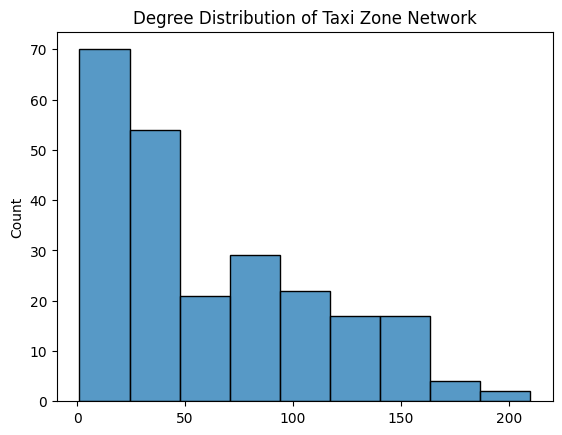

In [38]:
degrees=[]
for n in G.nodes():
    degrees.append(G.degree[n])

len(degrees)

sns.histplot(x=degrees).set_title('Degree Distribution of Taxi Zone Network');

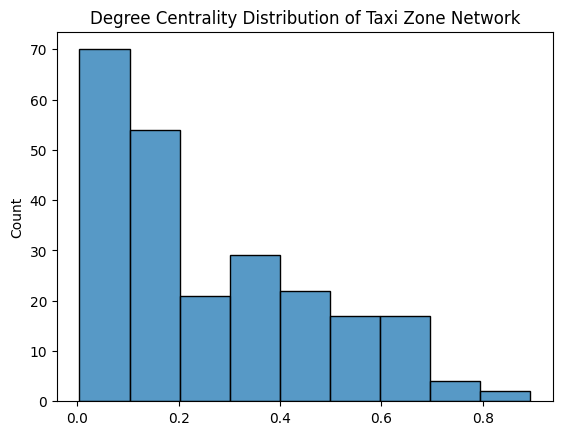

In [39]:
x=list(nx.degree_centrality(G).values())
sns.histplot(x=x).set_title('Degree Centrality Distribution of Taxi Zone Network');

As we can see, most nodes have very few connections and a small number of nodes are extremely well-connected. This **right-skewed distribution** is a common pattern in real-world networks — sometimes described as a *scale-free* network, where a few hubs dominate connectivity.

### Shortest Path

A classic question in network analysis is: *what is the shortest path between two nodes?* In other words, what is the minimum number of edges (hops) we must traverse to get from one node to another?

NetworkX's `nx.shortest_path()` uses breadth-first search to answer this quickly, even for large graphs. In the context of our taxi network, the shortest path tells us the minimum number of zone-to-zone connections needed to link any two zones.

We pick two zones at random and then compute the shortest path between them.

In [40]:
zone1=random.choice(nodes)
z1name=zone_name[zone1]
zone2=random.choice(nodes)
z2name=zone_name[zone2]

print(f'First random zone: {zone1} ({z1name})\nSecond random zone: {zone2} ({z2name})')

First random zone: 15 (Bay Terrace/Fort Totten)
Second random zone: 211 (SoHo)


In [41]:
path=nx.shortest_path(G, source=zone1, target=zone2)
path_string=[f'{p}: {zone_name[p]}' for p in path]
print(f'Shortest path from zone {zone1} ({z1name}) to zone {zone2} ({z2name}) --> {path_string}')

Shortest path from zone 15 (Bay Terrace/Fort Totten) to zone 211 (SoHo) --> ['15: Bay Terrace/Fort Totten', '230: Times Sq/Theatre District', '211: SoHo']


### Clustering

We are often interested in identifying **clusters** — groups of nodes that are densely interconnected. One of the simplest cluster measures is the **triangle**: three nodes where each is connected to the other two.

NetworkX can count the number of triangles that include any given node. A high triangle count suggests that a zone's neighbors are also connected to each other — indicating a tight local cluster. Let's pick a random zone and check its triangle count.

In [42]:
zone=random.choice(nodes)

triangles=nx.triangles(G, zone)

print(f'Zone {zone} ({zone_name[zone]}) has {triangles} triangles.')

Zone 114 (Greenwich Village South) has 5112 triangles.


Transitivity is another way to think about how clustered your network is. Transitivity represents the number of triangles in your data as a proportion of the total possible triangles. According to the Networkx documentation: "Possible triangles are identified by the number of “triads” (two edges with a shared vertex)." https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cluster.transitivity.html

$$
T=3\frac{\#triangles}{\#triads}
$$

In [43]:
transitivity=nx.transitivity(G)
print(f'The transitivity of our network is: {transitivity}')

The transitivity of our network is: 0.6047409569477744


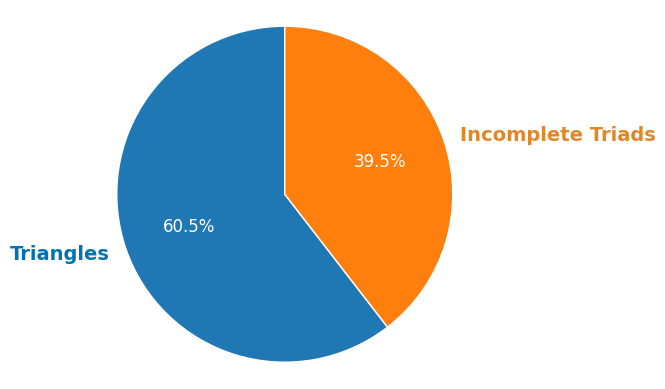

In [44]:
# Data
sizes = [transitivity, 1-transitivity]
labels = ['Triangles', 'Incomplete Triads']
colors = ['#0072b5ff', '#e18727ff']

# Create the pie chart
patches, texts, autotexts =plt.pie( sizes, wedgeprops=dict(edgecolor='w'),
                                    labels=labels, autopct='%1.1f%%',
                                    startangle=90)

# Customize external labels
for i, t in enumerate(texts):
    t.set_color(colors[i])
    t.set_fontsize(14)
    t.set_fontweight('bold')

# Customize internal percentage labels
for at in autotexts:
    at.set_color('white')
    at.set_fontsize(12)
    
# Ensure the plot is a circle
plt.axis('equal') 

# Display the chart
plt.show()

### Neighbors

The final analysis we will look at is identifying the **neighbors** of a given node — that is, all nodes that share a direct edge with it. This is closely related to degree (which counts the neighbors), but here we want to see *which specific nodes* are connected to a given node.

In our dataset, every node must have at least one neighbor because every taxi zone that appears as a pickup must also appear as a dropoff somewhere. Let's find all zones with exactly one neighbor and identify who that neighbor is.

In [45]:
#find all nodes with only one neighbor
one_nbor=[]
for n in G.nodes():
    if G.degree[n]==1:
        one_nbor.append(n)

zone_string=[str(z)+' ('+zone_name[z]+')'for z in one_nbor]
print(f'Zones with only one neighbor: {zone_string}')

Zones with only one neighbor: ['30 (Broad Channel)', '27 (Breezy Point/Fort Tilden/Riis Beach)', '59 (Crotona Park)']


In [46]:
#now let's find their neighbor
for z in one_nbor:
    nbor_list=[n for n in G.neighbors(z)] #returns iterator for neighbors of node z
    print(f'Zone: {z}: ({zone_name[z]}) - Neighbor: {zone_name[nbor_list[0]]}')

Zone: 30: (Broad Channel) - Neighbor: LaGuardia Airport
Zone: 27: (Breezy Point/Fort Tilden/Riis Beach) - Neighbor: JFK Airport
Zone: 59: (Crotona Park) - Neighbor: East Harlem North


---
## Conclusion

In this workshop we built a real-world network from NYC taxi trip data and applied several fundamental network analysis techniques:

| Concept | What it tells us |
|---|---|
| **Degree / Centrality** | How connected a node is relative to the rest of the network |
| **Shortest Path** | The minimum number of hops between any two nodes |
| **Triangles / Transitivity** | How clustered or tight-knit the network is |
| **Neighbors** | Which nodes are directly connected to a given node |

The analyses we can do on network data are virtually endless. For more examples, algorithms, and visualizations, refer to the [NetworkX documentation](https://networkx.org/documentation/stable/index.html).